In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Machine Learning/train.csv')

df.head()

Mounted at /content/drive


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Option A: Built-in dataset (no download needed)
data = fetch_california_housing(as_frame=True)
df = data.frame
print(df.shape, df.head())

# Option B: Kaggle CSV uploaded to Drive
# df = pd.read_csv('/content/drive/MyDrive/Machine Learning/train.csv')

(20640, 9)    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Check nulls
print("Nulls:\n", df.isnull().sum())
df.dropna(inplace=True)

# 2. Remove outliers using IQR on target
Q1, Q3 = df['MedHouseVal'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df = df[(df['MedHouseVal'] >= Q1-1.5*IQR) &
        (df['MedHouseVal'] <= Q3+1.5*IQR)]

# 3. Feature selection via correlation
corr = df.corr()['MedHouseVal'].abs().sort_values(ascending=False)
top_features = corr[1:6].index.tolist()  # top 5 features
print("Selected features:", top_features)

X = df[top_features].values
y = df['MedHouseVal'].values

# 4. Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Nulls:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
Selected features: ['MedInc', 'Latitude', 'AveRooms', 'AveBedrms', 'HouseAge']
Train: (15655, 5), Test: (3914, 5)


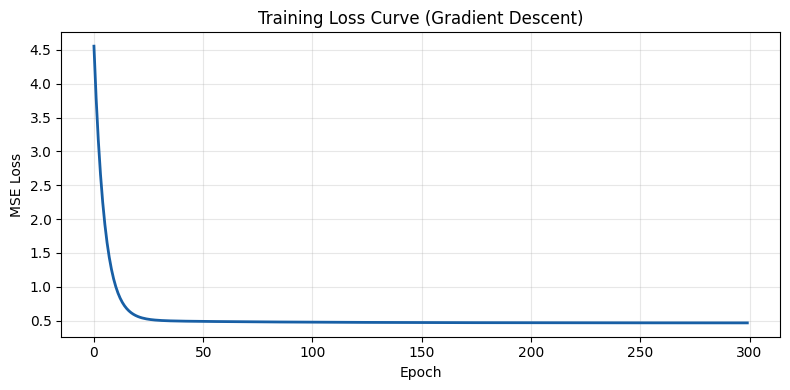

In [ ]:
def gradient_descent(X, y, lr=0.01, epochs=500):
    m, n = X.shape
    X_b = np.c_[np.ones((m,1)), X]   # add bias
    theta = np.zeros(n+1)
    losses = []
    for i in range(epochs):
        preds = X_b @ theta
        errors = preds - y
        loss = (errors**2).mean()
        losses.append(loss)
        grad = (2/m) * X_b.T @ errors
        theta -= lr * grad
    return theta, losses

theta, losses = gradient_descent(X_train, y_train, lr=0.05, epochs=300)

# --- SCREENSHOT 1: Loss Curve ---
plt.figure(figsize=(8,4))
plt.plot(losses, color='#185FA5', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Curve (Gradient Descent)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/loss_curve.png', dpi=150)
plt.show()

MAE:  0.5003
MSE:  0.4336
RMSE: 0.6585
R²:   0.5311


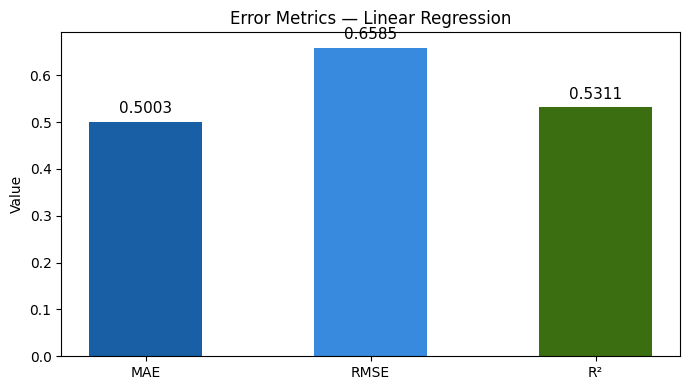

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# --- SCREENSHOT 2: Metrics Bar Chart ---
fig, ax = plt.subplots(figsize=(7,4))
metrics = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
colors  = ['#185FA5','#378ADD','#3B6D11']
bars = ax.bar(metrics.keys(), metrics.values(), color=colors, width=0.5)
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=11)
ax.set_title('Error Metrics — Linear Regression')
ax.set_ylabel('Value')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/metrics.png', dpi=150)
plt.show()

 Actual  Predicted  Error
  0.552      1.133  0.581
  0.978      1.164  0.186
  2.453      2.253 -0.200
  1.621      1.503 -0.118
  1.631      2.021  0.390
  3.509      2.531 -0.978
  2.266      2.344  0.078
  4.438      3.493 -0.945
  1.625      2.688  1.063
  0.894      1.031  0.137


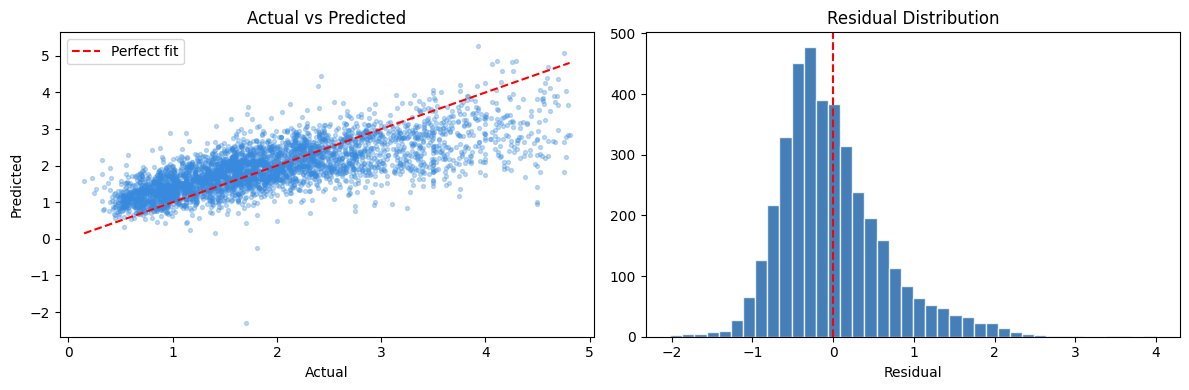

In [ ]:
import pandas as pd

# --- SCREENSHOT 3: Sample Predictions Table & Scatter ---
sample = pd.DataFrame({
    'Actual':    y_test[:10].round(3),
    'Predicted': y_pred[:10].round(3),
    'Error':     (y_pred[:10]-y_test[:10]).round(3)
})
print(sample.to_string(index=False))

fig, axes = plt.subplots(1,2, figsize=(12,4))

# Scatter: actual vs predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, s=8, color='#378ADD')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn,mx],[mn,mx],'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted'); axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].hist(residuals, bins=40, color='#185FA5', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual'); axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/predictions.png', dpi=150)
plt.show()